# DSDBA - Training Notebook Scaffold (Production-Ready for Phase 3)

This notebook scaffolds Phase 3 environment setup and the Q3 VRAM gate for EfficientNet-B4.

Training loop itself is intentionally deferred to later chains (Sprint B / Chain 06).

In [1]:
!git clone https://github.com/ibrahimferel/final-fried-kcv.git
%cd DSDBA

Cloning into 'final-fried-kcv'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 80 (delta 0), reused 1 (delta 0), pack-reused 73 (from 1)
Receiving objects: 100% (80/80), 127.09 MiB | 23.74 MiB/s, done.
Resolving deltas: 100% (4/4), done.
[Errno 2] No such file or directory: 'DSDBA'
/content


In [2]:
import os
os.environ["DSDBA_REPO_URL"] = "https://github.com/ibrahimferel/final-fried-kcv.git"

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install torch torchvision torchaudio librosa numpy gradio grad-cam onnxruntime pydantic datasets huggingface-hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 110.1 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=a11d9afd2a218e81a44b60779d1b3cc9cc17fe09c9d504f4d74ad3892d1513fd
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [5]:
# Simple & clean
import sys
sys.path.append("/content/final-fried-kcv")

from pathlib import Path
import os

os.chdir("/content/final-fried-kcv")
print("Working dir:", Path.cwd())

Working dir: /content/final-fried-kcv


In [6]:
# Cell X — Single source of truth for Colab + Drive paths
from pathlib import Path
import yaml

cfg_path = Path("/content/final-fried-kcv/config.yaml")
cfg = yaml.safe_load(cfg_path.read_text())

# Drive roots (edit only these values if needed)
DATASET_ROOT = "/content/drive/MyDrive/dsdba-fix/dataset"
PREPROCESSED_ROOT = "/content/drive/MyDrive/dsdba-fix/preprocessed"
CHECKPOINT_ROOT = "/content/drive/MyDrive/dsdba-fix/models/checkpoints"
BEST_CHECKPOINT_FILENAME = "best_model.pth"
RESUME_CHECKPOINT = ""  # example: "/content/drive/MyDrive/DSDBA/models/checkpoints/epoch_10.pth"

cfg["training"]["dataset_root"] = DATASET_ROOT
cfg["training"]["preprocessed_root"] = PREPROCESSED_ROOT
cfg["training"]["checkpoint_root"] = CHECKPOINT_ROOT
cfg["training"]["best_checkpoint_filename"] = BEST_CHECKPOINT_FILENAME
cfg["training"]["resume_checkpoint"] = RESUME_CHECKPOINT

cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
print("config.yaml updated with Drive paths:")
print("- dataset_root:", cfg["training"]["dataset_root"])
print("- preprocessed_root:", cfg["training"]["preprocessed_root"])
print("- checkpoint_root:", cfg["training"]["checkpoint_root"])
print("- best_checkpoint_filename:", cfg["training"]["best_checkpoint_filename"])
print("- resume_checkpoint:", cfg["training"]["resume_checkpoint"])


config.yaml updated with Drive paths:
- dataset_root: /content/drive/MyDrive/dsdba-fix/dataset
- preprocessed_root: /content/drive/MyDrive/dsdba-fix/preprocessed
- checkpoint_root: /content/drive/MyDrive/dsdba-fix/models/checkpoints
- best_checkpoint_filename: best_model.pth
- resume_checkpoint: 


# SAFA

In [ ]:
import os
import torch
import yaml
import sys
sys.path.insert(0, '/content/final-fried.kcv')

from src.audio.dsp import preprocess_audio
from pathlib import Path

with open('/content/final-fried.kcv/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

for split in ['train', 'validation']:
    for label in ['bonafide', 'spoof']:
        src = f'/content/final-fried.kcv/data/{split}/{label}'
        dst = f'/content/final-fried.kcv/data_cached/{split}/{label}'
        os.makedirs(dst, exist_ok=True)
        files = list(Path(src).glob('*.wav')) + list(Path(src).glob('*.flac'))
        print(f'Processing {split}/{label}: {len(files)} files')
        for i, f_path in enumerate(files):
            out = Path(dst) / (f_path.stem + '.pt')
            if not out.exists():
                tensor = preprocess_audio(f_path, cfg)
                torch.save(tensor, out)
            if i % 500 == 0:
                print(f'  {i}/{len(files)} done...')
print('✅ Cache selesai!')

Processing train/bonafide: 0 files
Processing train/spoof: 0 files
Processing validation/bonafide: 0 files
Processing validation/spoof: 0 files
✅ Cache selesai!


In [20]:
import torch
import torch.nn as nn
import sys
sys.path.insert(0, '/content/final-fried-kcv')

from src.cv.model import DSDBAModel
from src.cv.train import train_epoch, validate_epoch
import yaml

with open('/content/final-fried-kcv/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = DSDBAModel(cfg)
model = model.to(device)
model.freeze_backbone()

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3
)
criterion = nn.CrossEntropyLoss()

print('🚀 Training dimulai - Fase 1 (frozen backbone)')
best_auc = 0.0

for epoch in range(1, 6):
    train_metrics = train_epoch(model, train_loader, optimizer, criterion, cfg)
    val_metrics = validate_epoch(model, val_loader, cfg)

    # Print semua keys yang ada dulu
    print(f'Train metrics keys: {train_metrics.keys()}')
    print(f'Val metrics keys: {val_metrics.keys()}')

    auc = val_metrics.get('auc_roc', 0)
    eer = val_metrics.get('eer', 1)
    loss = train_metrics.get('loss', train_metrics.get('train_loss', 0))

    print(f'Epoch {epoch}/5 | Loss: {loss:.4f} | AUC-ROC: {auc:.4f} | EER: {eer:.4f}')

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), '/content/final-fried-kcv/best_model.pth')
        print(f'  ✅ Best model saved! AUC: {best_auc:.4f}')

print(f'\n🎉 Fase 1 selesai! Best AUC-ROC: {best_auc:.4f}')

Device: cuda
🚀 Training dimulai - Fase 1 (frozen backbone)


NameError: name 'train_loader' is not defined

In [ ]:
# Fase 2: unfreeze top layers, finetune
model.unfreeze_top_n(n=2)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4  # lr lebih kecil
)

print('🚀 Training Fase 2 (fine-tuning top layers)')
best_auc_ft = best_auc

for epoch in range(1, 6):
    train_metrics = train_epoch(model, train_loader, optimizer, criterion, cfg)
    val_metrics = validate_epoch(model, val_loader, cfg)
    auc = val_metrics.get('auc_roc', 0)
    eer = val_metrics.get('eer', 1)
    loss = train_metrics.get('train_loss', 0)
    print(f'FT Epoch {epoch}/5 | Loss: {loss:.4f} | AUC-ROC: {auc:.4f} | EER: {eer:.4f}')
    if auc > best_auc_ft:
        best_auc_ft = auc
        torch.save(model.state_dict(), '/content/drive/MyDrive/dsdba_cache/best_model.pth')
        print(f'  ✅ Best model saved! AUC: {best_auc_ft:.4f}')

print(f'\n🎉 Fase 2 selesai! Best AUC-ROC: {best_auc_ft:.4f}')

In [ ]:
# ============================================================================
# Fine-tune dari preprocessed .pt (train + validation)
# ============================================================================
#
# Prasyarat:
#   - Cell 6 (config.yaml paths) sudah dijalankan
#   - Folder preprocessed sudah ada:
#       {preprocessed_root}/train/bonafide/*.pt
#       {preprocessed_root}/train/spoof/*.pt
#       {preprocessed_root}/validation/bonafide/*.pt
#       {preprocessed_root}/validation/spoof/*.pt
#
# Pipeline:
#   1. Load .pt tensors ke Dataset/DataLoader
#   2. Fase 1: head-only (backbone frozen), 5 epoch
#   3. Fase 2: unfreeze top-N blok + head, 10 epoch, lr lebih kecil
#   4. Early stopping berdasar AUC-ROC pada validation
#   5. Simpan best_model.pth ke Drive
#
# Setelah selesai: jalankan Cell 8 → Cell 9 untuk evaluasi test.
# ============================================================================

import os
import sys
import time
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import yaml
from torch.utils.data import DataLoader, Dataset

sys.path.insert(0, '/content/final-fried-kcv')

from src.cv.model import DSDBAModel
from src.cv.train import (
    compute_eer,
    get_class_weights,
    build_augmentations,
    train_epoch,
    validate_epoch,
)
from sklearn.metrics import roc_auc_score

cfg = yaml.safe_load(Path('/content/final-fried-kcv/config.yaml').read_text())

# ── Resume mode ──────────────────────────────────────────────────────────────
# Set True untuk lanjut dari checkpoint terakhir (skip Fase 1).
# Set False untuk training ulang dari awal (Fase 1 + 2).
RESUME_PHASE2 = True
RESUME_BEST_AUC = 0.927230   # AUC terbaik saat crash — update jika berbeda

# ── Hyperparams (tweak di sini) ──────────────────────────────────────────────
PHASE1_EPOCHS = 5            # head-only
PHASE2_EPOCHS = 15           # fine-tune (unfreeze top blok)
PHASE1_LR = 1e-3             # lr fase 1
PHASE2_LR = 5e-5             # lr fase 2 (lebih kecil = lebih stabil)
UNFREEZE_BLOCKS = 3          # jumlah blok EfficientNet yang di-unfreeze di fase 2
PATIENCE = 5                 # early stopping patience
BATCH_SIZE = int(cfg['training'].get('batch_size', 16))
NUM_WORKERS = 2
USE_AMP = True               # mixed precision (T4/A100)

# ── Paths ────────────────────────────────────────────────────────────────────
pre_root = Path(cfg['training']['preprocessed_root'])
ckpt_dir = Path(cfg['training']['checkpoint_root'])
ckpt_dir.mkdir(parents=True, exist_ok=True)
best_ckpt = ckpt_dir / cfg['training']['best_checkpoint_filename']

# ── Dataset: load preprocessed .pt ────────────────────────────────────────
class PreprocessedDataset(Dataset):
    def __init__(self, root: Path, transform=None):
        self.items = []
        self.labels = []
        self.transform = transform
        for label_name, y in (('bonafide', 0), ('spoof', 1)):
            d = root / label_name
            if not d.is_dir():
                raise FileNotFoundError(f'Folder tidak ada: {d}')
            for p in sorted(d.glob('*.pt')):
                self.items.append(p)
                self.labels.append(y)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        t = torch.load(self.items[idx], map_location='cpu')
        if t.ndim == 4:
            t = t.squeeze(0)
        t = t.to(dtype=torch.float32)
        if self.transform is not None:
            t = self.transform(t)
        return t, int(self.labels[idx])

augment_fn = build_augmentations(cfg)

train_dataset = PreprocessedDataset(pre_root / 'train', transform=augment_fn)
val_dataset   = PreprocessedDataset(pre_root / 'validation', transform=None)

print(f'Train: {len(train_dataset)} (bonafide={sum(1 for y in train_dataset.labels if y==0)}, spoof={sum(1 for y in train_dataset.labels if y==1)})')
print(f'Val:   {len(val_dataset)} (bonafide={sum(1 for y in val_dataset.labels if y==0)}, spoof={sum(1 for y in val_dataset.labels if y==1)})')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ── Model + loss ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DSDBAModel(cfg=cfg, pretrained=True).to(device)

class_weights = get_class_weights(train_dataset).to(device)
print(f'Class weights [bonafide, spoof]: {class_weights.tolist()}')
criterion = nn.CrossEntropyLoss(weight=class_weights)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device.type == 'cuda')

if RESUME_PHASE2:
    # ── Resume: skip Fase 1, load checkpoint langsung ────────────────────────
    assert best_ckpt.exists(), f'Checkpoint tidak ditemukan: {best_ckpt}'
    model.load_state_dict(torch.load(str(best_ckpt), map_location=device))
    best_auc = RESUME_BEST_AUC
    print(f'\n⏩ RESUME MODE: Fase 1 di-skip.')
    print(f'   Loaded checkpoint: {best_ckpt}')
    print(f'   Melanjutkan dari best AUC={best_auc:.6f}')
else:
    # ── Fase 1: head-only ────────────────────────────────────────────────────
    model.freeze_backbone()
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=PHASE1_LR,
        weight_decay=1e-2,
    )

    best_auc = -math.inf
    no_improve = 0

    print(f'\n=== Fase 1: Head-only ({PHASE1_EPOCHS} epochs, lr={PHASE1_LR}) ===')
    for epoch in range(1, PHASE1_EPOCHS + 1):
        t0 = time.time()
        train_m = train_epoch(model, train_loader, optimizer, criterion, cfg, scaler=scaler)
        val_m = validate_epoch(model, val_loader, cfg)
        elapsed = time.time() - t0
        auc = val_m['auc_roc']
        eer = val_m['eer']
        loss = train_m['train_loss']
        acc = train_m['train_acc']
        print(f'  Epoch {epoch}/{PHASE1_EPOCHS} | loss={loss:.4f} acc={acc:.4f} | AUC={auc:.4f} EER={eer:.4f} | {elapsed:.1f}s')
        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), str(best_ckpt))
            print(f'    ✅ Best model (AUC={best_auc:.6f}) saved → {best_ckpt}')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'    Early stop (patience={PATIENCE})')
                break

# ── Fase 2: unfreeze top blok ────────────────────────────────────────────────
model.load_state_dict(torch.load(str(best_ckpt), map_location=device))
model.unfreeze_top_n(n=UNFREEZE_BLOCKS)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=PHASE2_LR,
    weight_decay=1e-2,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-6)

no_improve = 0
print(f'\n=== Fase 2: Fine-tune top-{UNFREEZE_BLOCKS} blok ({PHASE2_EPOCHS} epochs, lr={PHASE2_LR}) ===')
for epoch in range(1, PHASE2_EPOCHS + 1):
    t0 = time.time()
    train_m = train_epoch(model, train_loader, optimizer, criterion, cfg, scaler=scaler)
    val_m = validate_epoch(model, val_loader, cfg)
    scheduler.step()
    elapsed = time.time() - t0
    auc = val_m['auc_roc']
    eer = val_m['eer']
    loss = train_m['train_loss']
    acc = train_m['train_acc']
    current_lr = optimizer.param_groups[0]['lr']
    print(f'  Epoch {epoch}/{PHASE2_EPOCHS} | loss={loss:.4f} acc={acc:.4f} | AUC={auc:.4f} EER={eer:.4f} | lr={current_lr:.2e} | {elapsed:.1f}s')
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), str(best_ckpt))
        print(f'    ✅ Best model (AUC={best_auc:.6f}) saved → {best_ckpt}')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'    Early stop (patience={PATIENCE})')
            break

# ── Done ─────────────────────────────────────────────────────────────────────
model.load_state_dict(torch.load(str(best_ckpt), map_location=device))
model.eval()
print(f'\n🎉 Fine-tune selesai! Best AUC-ROC (val): {best_auc:.6f}')
print(f'Checkpoint: {best_ckpt}')
print('\nLanjut: jalankan Cell 8 (load checkpoint) → Cell 9 (evaluasi test).')


In [ ]:
from src.cv.infer import export_to_onnx, verify_onnx_equivalence

# Load best model dulu
model.load_state_dict(torch.load('/content/drive/MyDrive/dsdba-fix/models/best_model.pth'))
model.eval()

# Export ke ONNX
onnx_path = export_to_onnx(model, cfg)
print(f'ONNX saved: {onnx_path}')

# Verifikasi
ok = verify_onnx_equivalence(model, onnx_path, cfg)
print(f'ONNX equivalence: {ok}')

# Simpan ke Drive
import shutil
shutil.copy(onnx_path, '/content/drive/MyDrive/dsdba-fix/models/model.onnx')
print('✅ Model ONNX tersimpan di Drive!')

In [11]:
# HF login: token dari env atau Colab Secrets — jangan hardcode token di notebook.
import os
from huggingface_hub import login

HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = None

assert HF_TOKEN, "Missing HF_TOKEN. Set Runtime → Secrets (name: HF_TOKEN) in Colab, or export HF_TOKEN."

login(token=HF_TOKEN)
print("Hugging Face login OK.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Hugging Face login OK.


In [12]:
from huggingface_hub import HfApi

api = HfApi()

api.create_repo(
    repo_id="ibrahimferel/dsdba-efficientnet-b4",  # ganti username
    repo_type="model",
    private=False,
    exist_ok=True
)

RepoUrl('https://huggingface.co/ibrahimferel/dsdba-efficientnet-b4', endpoint='https://huggingface.co', repo_type='model', repo_id='ibrahimferel/dsdba-efficientnet-b4')

In [22]:
from huggingface_hub import HfApi

api = HfApi()

# Upload checkpoint PyTorch
api.upload_file(
    path_or_fileobj="/content/drive/MyDrive/dsdba-fix/models/checkpoints/best_model.pth",
    path_in_repo="best_model.pth",                   # nama di repo HF
    repo_id="ibrahimferel/dsdba-efficientnet-b4",
    repo_type="model",
    commit_message="Upload best model checkpoint - AUC 0.9726"
)

api.upload_file(
    path_or_fileobj="/content/drive/MyDrive/dsdba-fix/models/checkpoints/dsdba_efficientnet_b4.onnx",
    path_in_repo="model.onnx",
    repo_id="ibrahimferel/dsdba-efficientnet-b4",
    repo_type="model",
    commit_message="Upload ONNX model for CPU inference"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...heckpoints/best_model.pth: 100%|##########| 71.0MB / 71.0MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...sdba_efficientnet_b4.onnx:  10%|#         | 7.13MB / 70.1MB            

CommitInfo(commit_url='https://huggingface.co/ibrahimferel/dsdba-efficientnet-b4/commit/08c48da1635313c46a823abf644d2a12c738e292', commit_message='Upload ONNX model for CPU inference', commit_description='', oid='08c48da1635313c46a823abf644d2a12c738e292', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ibrahimferel/dsdba-efficientnet-b4', endpoint='https://huggingface.co', repo_type='model', repo_id='ibrahimferel/dsdba-efficientnet-b4'), pr_revision=None, pr_num=None)

# FEREL LAGI

In [7]:
# [DSDBA] Cell 8 — load checkpoint untuk Cell 9 (evaluasi formal test set)
# Cell 8 — Load BEST checkpoint dari Drive (Chain 07 / evaluasi formal)
# Jalankan sebelum Cell 9: evaluasi AUC / EER / confusion matrix pada folder `test`.
from pathlib import Path
import torch
import yaml

from src.cv.model import DSDBAModel

cfg = yaml.safe_load(Path("config.yaml").read_text())
ckpt_dir = Path(cfg["training"]["checkpoint_root"])
best_ckpt = ckpt_dir / cfg["training"]["best_checkpoint_filename"]

assert best_ckpt.exists(), f"Best checkpoint not found: {best_ckpt}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DSDBAModel(cfg=cfg, pretrained=False).to(device)

state = torch.load(best_ckpt, map_location=device)

# 🔥 FIX: langsung load
model.load_state_dict(state)

model.eval()

print("Loaded best checkpoint:", best_ckpt)
print("Total parameters loaded:", len(state))



Loaded best checkpoint: /content/drive/MyDrive/dsdba-fix/models/checkpoints/best_model.pth
Total parameters loaded: 706


{"timestamp": "2026-04-02T07:33:45.456022+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 2937.994, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115223315.png", "band_attr": {"low": 22.773145252501816, "low_mid": 33.38432256232166, "high_mid": 17.326724503006062, "high": 26.51580768217047}}}


--------------------------------------------------------------------------------
Sample: file10035.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.995289
Softmax [bonafide, spoof]: [0.004711, 0.995289]
Band attributions (%): {'low': 22.7731, 'low_mid': 33.3843, 'high_mid': 17.3267, 'high': 26.5158}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115223315.png


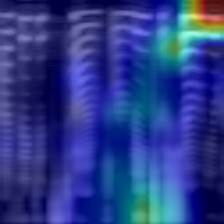

{"timestamp": "2026-04-02T07:33:46.218120+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 141.907, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115226201.png", "band_attr": {"low": 9.442106752422347, "low_mid": 39.36175573492054, "high_mid": 18.021173328152965, "high": 33.17496418450414}}}


--------------------------------------------------------------------------------
Sample: file10038.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 0.828942
Softmax [bonafide, spoof]: [0.171058, 0.828942]
Band attributions (%): {'low': 9.4421, 'low_mid': 39.3618, 'high_mid': 18.0212, 'high': 33.175}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115226201.png


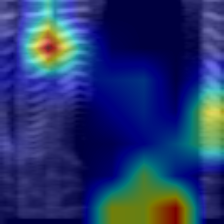

{"timestamp": "2026-04-02T07:33:46.974063+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 92.638, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115226952.png", "band_attr": {"low": 16.938551952554377, "low_mid": 26.031788384535314, "high_mid": 4.4495612651231875, "high": 52.580098397787125}}}


--------------------------------------------------------------------------------
Sample: file10039.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: spoof
Predicted: spoof | confidence: 1.0
Softmax [bonafide, spoof]: [0.0, 1.0]
Band attributions (%): {'low': 16.9386, 'low_mid': 26.0318, 'high_mid': 4.4496, 'high': 52.5801}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115226952.png


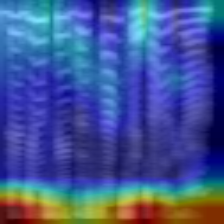

{"timestamp": "2026-04-02T07:33:47.743568+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 89.087, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115227725.png", "band_attr": {"low": 0.9169273861015572, "low_mid": 66.80700479017781, "high_mid": 32.15777717944096, "high": 0.1182906442796654}}}


--------------------------------------------------------------------------------
Sample: file10004.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.999995
Softmax [bonafide, spoof]: [0.999995, 5e-06]
Band attributions (%): {'low': 0.9169, 'low_mid': 66.807, 'high_mid': 32.1578, 'high': 0.1183}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115227725.png


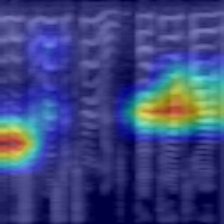

{"timestamp": "2026-04-02T07:33:48.540678+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 90.067, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115228522.png", "band_attr": {"low": 10.011176046369098, "low_mid": 73.36541293802964, "high_mid": 15.249887850689056, "high": 1.3735231649122235}}}


--------------------------------------------------------------------------------
Sample: file10022.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.999646
Softmax [bonafide, spoof]: [0.999646, 0.000354]
Band attributions (%): {'low': 10.0112, 'low_mid': 73.3654, 'high_mid': 15.2499, 'high': 1.3735}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115228522.png


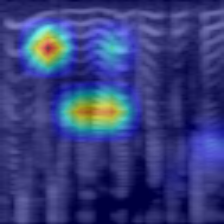

{"timestamp": "2026-04-02T07:33:49.309040+00:00", "level": "INFO", "stage": "cv_gradcam", "message": "gradcam_complete", "data": {"latency_ms": 103.037, "heatmap_path": "/content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115229291.png", "band_attr": {"low": 6.214355330032429, "low_mid": 83.41407725219138, "high_mid": 10.36922567920496, "high": 0.002341738571232521}}}


--------------------------------------------------------------------------------
Sample: file1005.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt
Expected: bonafide
Predicted: bonafide | confidence: 0.999998
Softmax [bonafide, spoof]: [0.999998, 2e-06]
Band attributions (%): {'low': 6.2144, 'low_mid': 83.4141, 'high_mid': 10.3692, 'high': 0.0023}
Heatmap: /content/final-fried-kcv/outputs/gradcam/gradcam_overlay_1775115229291.png


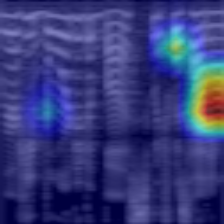

Summary (4 samples):
1. file10035.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof conf=0.9953
2. file10038.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof conf=0.8289
3. file10039.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=spoof pred=spoof conf=1.0000
4. file10004.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=bonafide pred=bonafide conf=1.0000
5. file10022.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=bonafide pred=bonafide conf=0.9996
6. file1005.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.pt | exp=bonafide pred=bonafide conf=1.0000


In [8]:
# Cell 9 — Evaluasi formal FoR: split `test` (tensor .pt hasil DSP)
# [DSDBA] Diperbarui: inferensi batch, AUC/EER/confusion matrix, CSV opsional.
# Path: `{preprocessed_root}/test/bonafide/*.pt` dan `.../spoof/*.pt`
# Metrik: AUC-ROC, EER (protokol sama `src/cv/train.py` validate_epoch), confusion matrix.
# Skor spoof = sigmoid(logits[:,1]) — konsisten dengan validasi training & infer ONNX.
from pathlib import Path
import csv
import torch
import yaml
import numpy as np

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **k: x

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from IPython.display import Markdown, display
from PIL import Image

from src.cv.gradcam import run_gradcam
from src.cv.train import compute_eer

cfg = yaml.safe_load(Path("config.yaml").read_text())
pre_root = Path(cfg["training"]["preprocessed_root"]) / "test"
threshold = float(cfg["model"].get("decision_threshold", 0.5))

# --- opsional ---
EVAL_MAX_FILES = None  # None = semua file; atau mis. 2000 untuk uji cepat
# Batch inferensi = training.batch_size di config.yaml (proyek ini: 16)
BATCH_SIZE = int(cfg["training"].get("batch_size", 16))
SAVE_PREDICTIONS_CSV = True  # simpan CSV di folder test
NUM_GRADCAM_SAMPLES = 0  # >0 untuk Grad-CAM pada N sampel pertama (lambat)


def _load_pt(path: Path) -> torch.Tensor:
    t = torch.load(path, map_location="cpu")
    if t.ndim == 4:
        t = t.squeeze(0)
    return t.to(dtype=torch.float32)


def _collect_items() -> list[tuple[Path, int]]:
    out: list[tuple[Path, int]] = []
    for label_name, y in (("bonafide", 0), ("spoof", 1)):
        d = pre_root / label_name
        if not d.is_dir():
            raise FileNotFoundError(f"Folder tidak ada: {d}")
        for p in sorted(d.glob("*.pt")):
            out.append((p, y))
    return out


assert "model" in globals() and "device" in globals(), "Jalankan Cell 8 dulu (load checkpoint)."

items = _collect_items()
if not items:
    raise RuntimeError(f"Tidak ada file .pt di bawah {pre_root}")

if EVAL_MAX_FILES is not None:
    items = items[: int(EVAL_MAX_FILES)]

n_b = sum(1 for _, y in items if y == 0)
n_s = sum(1 for _, y in items if y == 1)
display(Markdown(
    f"**Evaluasi test** — `{pre_root}`  \n"
    f"Total **{len(items)}** file .pt (bonafide={n_b}, spoof={n_s})"
))

y_true: list[int] = []
y_score_spoof: list[float] = []
y_pred_argmax: list[int] = []
y_pred_thresh: list[int] = []
rows_out: list[dict[str, object]] = []

n_batches = (len(items) + BATCH_SIZE - 1) // BATCH_SIZE
for bi in tqdm(range(n_batches), desc="Inference"):
    chunk = items[bi * BATCH_SIZE : (bi + 1) * BATCH_SIZE]
    batch = torch.stack([_load_pt(p) for p, _ in chunk]).to(device)
    with torch.no_grad():
        logits = model(batch)
    scores = torch.sigmoid(logits[:, 1]).detach().cpu().numpy()
    pred_arg = torch.argmax(logits, dim=1).detach().cpu().numpy()
    pred_thr = (scores >= threshold).astype(np.int64)

    for j, (path, y) in enumerate(chunk):
        sc = float(scores[j])
        pa = int(pred_arg[j])
        pt = int(pred_thr[j])
        y_true.append(y)
        y_score_spoof.append(sc)
        y_pred_argmax.append(pa)
        y_pred_thresh.append(pt)
        rows_out.append(
            {
                "path": str(path),
                "y_true": y,
                "pred_argmax": pa,
                "pred_threshold": pt,
                "score_spoof_sigmoid": sc,
            }
        )

y_true_arr = np.asarray(y_true, dtype=np.int64)
y_score_arr = np.asarray(y_score_spoof, dtype=np.float64)

try:
    auc = float(roc_auc_score(y_true_arr, y_score_arr))
except ValueError as e:
    auc = float("nan")
    print("AUC tidak terhitung:", e)
eer = float(compute_eer(y_true_arr.tolist(), y_score_arr.tolist()))

labels_order = [0, 1]
target_names = ["bonafide", "spoof"]

cm_arg = confusion_matrix(y_true_arr, np.asarray(y_pred_argmax), labels=labels_order)
cm_thr = confusion_matrix(y_true_arr, np.asarray(y_pred_thresh), labels=labels_order)

print("\n=== AUC-ROC (skor = sigmoid logit spoof) ===")
print(f"AUC-ROC: {auc:.6f}")
print(f"EER:     {eer:.6f}")
print(f"Threshold keputusan (cfg): {threshold}")

print("\n=== Confusion matrix — prediksi = argmax(logits) [disarankan vs CE] ===")
print("Rows: y_true, Cols: y_pred")
print(cm_arg)
print(classification_report(y_true_arr, y_pred_argmax, labels=[0, 1], target_names=target_names, digits=4, zero_division=0))

print("\n=== Confusion matrix — prediksi = (score_spoof >= threshold) [seperti infer.py] ===")
print(cm_thr)
print(classification_report(y_true_arr, y_pred_thresh, labels=[0, 1], target_names=target_names, digits=4, zero_division=0))

if SAVE_PREDICTIONS_CSV:
    csv_path = pre_root / "eval_test_predictions.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(rows_out[0].keys()))
        w.writeheader()
        w.writerows(rows_out)
    print(f"\nCSV prediksi tersimpan: {csv_path}")

if NUM_GRADCAM_SAMPLES > 0:
    print("\n--- Grad-CAM (opsional, sampel pertama) ---")
    for pt_path, y_lbl in items[:NUM_GRADCAM_SAMPLES]:
        tensor = _load_pt(pt_path)
        x = tensor.unsqueeze(0).to(device)
        heatmap_path, band_attr = run_gradcam(tensor=x, model=model, cfg=cfg)
        print(pt_path.name, "expected_label=", y_lbl, "heatmap=", heatmap_path, "bands=", band_attr)
        display(Image.open(heatmap_path))



In [ ]:
# Cell 10 — Tune threshold pada split validation
# Output: threshold rekomendasi untuk menyeimbangkan miss spoof vs salah bonafide.
from pathlib import Path
import csv
import numpy as np
import torch
import yaml

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from IPython.display import Markdown, display

assert "model" in globals() and "device" in globals(), "Jalankan Cell 8 dulu (load checkpoint)"

cfg = yaml.safe_load(Path("config.yaml").read_text())
pre_root = Path(cfg["training"]["preprocessed_root"])

# Pilih split validasi. Kalau folder `validation` tidak ada, coba `val`.
val_split = "validation"
val_root = pre_root / val_split
if not (val_root / "bonafide").exists():
    alt = "val"
    alt_root = pre_root / alt
    if (alt_root / "bonafide").exists():
        val_split = alt
        val_root = alt_root
    else:
        raise FileNotFoundError(f"Tidak menemukan validation set di bawah: {pre_root}. Coba pastikan ada `{val_split}` / `val`")

threshold_default = float(cfg["model"].get("decision_threshold", 0.5))
# Risiko produk: batasi salah bonafide menjadi spoof. (FPR = FP/(FP+TN))
target_fpr_bonafide = float(cfg.get("acceptance_criteria", {}).get("target_eer", 0.10))

BATCH_SIZE = int(cfg["training"].get("batch_size", 16))

def _load_pt(path: Path) -> torch.Tensor:
    t = torch.load(path, map_location="cpu")
    if t.ndim == 4:
        t = t.squeeze(0)
    return t.to(dtype=torch.float32)

items = []

EVAL_MAX_FILES = None  # None = semua file; set angka untuk quick tuning
for label_name, y in (("bonafide", 0), ("spoof", 1)):
    d = val_root / label_name
    if not d.is_dir():
        raise FileNotFoundError(f"Folder tidak ada: {d}")
    for p in sorted(d.glob("*.pt")):
        items.append((p, y))

if EVAL_MAX_FILES is not None:
    items = items[: int(EVAL_MAX_FILES)]

n_b = sum(1 for _, y in items if y == 0)
n_s = sum(1 for _, y in items if y == 1)
if len(items) == 0:
    raise RuntimeError(f"Tidak ada file .pt di bawah {val_root}")

display(Markdown(f"**Threshold tuning — validation**\n"
                 f"Folder: `{val_root}`\n"
                 f"Total: {len(items)} (bonafide={n_b}, spoof={n_s})\n"
                 f"Default threshold: {threshold_default}\n"
                 f"Target FPR bonafide: {target_fpr_bonafide}"))

y_true = []
y_scores = []  # score_spoof = sigmoid(logit_1)

n_batches = (len(items) + BATCH_SIZE - 1) // BATCH_SIZE
for bi in range(n_batches):
    chunk = items[bi * BATCH_SIZE : (bi + 1) * BATCH_SIZE]
    batch = torch.stack([_load_pt(p) for p, _ in chunk]).to(device)
    with torch.no_grad():
        logits = model(batch)
    scores = torch.sigmoid(logits[:, 1]).detach().cpu().numpy()

    for j, (_, y) in enumerate(chunk):
        y_true.append(y)
        y_scores.append(float(scores[j]))

y_true_arr = np.asarray(y_true, dtype=np.int64)
y_scores_arr = np.asarray(y_scores, dtype=np.float64)

# ROC-based selection
fpr, tpr, thresholds = roc_curve(y_true_arr, y_scores_arr, pos_label=1)
auc = float(roc_auc_score(y_true_arr, y_scores_arr))

fnr = 1.0 - tpr
idx_eer = int(np.nanargmin(np.abs(fnr - fpr)))
threshold_eer = float(thresholds[idx_eer])
eer_est = float((fnr[idx_eer] + fpr[idx_eer]) / 2.0)

valid = np.where(fpr <= target_fpr_bonafide)[0]
if valid.size > 0:
    idx_risk = int(valid[np.nanargmax(tpr[valid])])
else:
    # Kalau tidak ada threshold yang memenuhi constraint, fallback ke threshold EER
    idx_risk = idx_eer

threshold_risk = float(thresholds[idx_risk])
spoof_recall_risk = float(tpr[idx_risk])
fpr_risk = float(fpr[idx_risk])

def _report(thr: float, name: str):
    y_pred = (y_scores_arr >= thr).astype(np.int64)
    cm = confusion_matrix(y_true_arr, y_pred, labels=[0, 1])
    # For label=1 (spoof): recall = TP/(TP+FN) = TPR
    tp = int(cm[1, 1])
    fn = int(cm[1, 0])
    fp = int(cm[0, 1])
    tn = int(cm[0, 0])
    recall_spoof = tp / max(1, tp + fn)
    fpr_bonafide = fp / max(1, fp + tn)
    print("\n---", name, "---")
    print(f"Threshold: {thr:.6f}")
    print(f"AUC-ROC (global): {auc:.6f}")
    print(f"Spoof recall (TPR): {recall_spoof:.6f}")
    print(f"Bonafide FPR: {fpr_bonafide:.6f}")
    print("Confusion matrix (rows=true [bonafide, spoof], cols=pred [bonafide, spoof]):")
    print(cm)
    print(classification_report(y_true_arr, y_pred, labels=[0, 1], target_names=["bonafide", "spoof"], digits=4, zero_division=0))

print("\n### ROC summary (validation) ###")
print(f"AUC-ROC: {auc:.6f}")
print(f"EER threshold: {threshold_eer:.6f} (EER est={eer_est:.6f})")
print(f"Risk threshold (FPR bonafide <= {target_fpr_bonafide}): {threshold_risk:.6f}")

_report(threshold_default, "Default threshold (cfg)")
_report(threshold_eer, "Threshold EER-min")
_report(threshold_risk, "Threshold risk-aware")

# (Opsional) patch config:
# cfg["model"]["decision_threshold"] = threshold_risk
# Path("config.yaml").write_text(yaml.safe_dump(cfg, sort_keys=False), encoding="utf-8")

# --- Sweep threshold (validation; skor = sigmoid logit spoof) ---
# Range otomatis: dari EER threshold -0.15 sampai 0.99, atau 0.10–0.99 jika EER sangat rendah
SWEEP_THR_MIN = max(0.10, threshold_eer - 0.15)
SWEEP_THR_MAX = 0.99
SWEEP_N = 50  # step kecil agar presisi tinggi

print("\n### Sweep threshold (validation):", SWEEP_THR_MIN, "–", SWEEP_THR_MAX, "###")
hdr = ("thr", "acc", "rec_spoof", "rec_bon", "fpr_bon", "f1_macro")
print("\t".join(hdr))
sweep_rows = []
for thr in np.linspace(SWEEP_THR_MIN, SWEEP_THR_MAX, SWEEP_N):
    y_pred = (y_scores_arr >= thr).astype(np.int64)
    cm = confusion_matrix(y_true_arr, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    n = tp + tn + fp + fn
    acc = (tp + tn) / max(1, n)
    recall_spoof = tp / max(1, tp + fn)
    recall_bon = tn / max(1, tn + fp)
    fpr_bon = fp / max(1, fp + tn)
    f1m = float(f1_score(y_true_arr, y_pred, average="macro", zero_division=0))
    sweep_rows.append((float(thr), acc, recall_spoof, recall_bon, fpr_bon, f1m))
    print(
        f"{thr:.4f}\t{acc:.4f}\t{recall_spoof:.4f}\t{recall_bon:.4f}\t{fpr_bon:.4f}\t{f1m:.4f}"
    )

csv_sweep = val_root / "threshold_sweep_validation.csv"
with csv_sweep.open("w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["threshold", "accuracy", "recall_spoof", "recall_bonafide", "fpr_bonafide", "f1_macro"])
    for row in sweep_rows:
        w.writerow([f"{row[0]:.6f}"] + [f"{x:.6f}" for x in row[1:]])
print(f"\nCSV sweep tersimpan: {csv_sweep}")


In [ ]:
# # Cell 2 — Reproducibility
# import random
# import numpy as np
# import torch

# SEED = 42

# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# torch.cuda.manual_seed_all(SEED)

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

# try:
#     torch.use_deterministic_algorithms(True)
# except Exception as e:
#     print("Deterministic algorithms not fully enabled:", e)

# print("Seeds set:", SEED)

In [ ]:
# import torch
# import onnxruntime as ort
# import numpy as np

# # Test manual
# dummy = torch.randn(1, 3, 224, 224)

# # Output PyTorch
# model_cpu.eval()
# with torch.no_grad():
#     pt_out = model_cpu(dummy).numpy()

# # Output ONNX
# session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])
# onnx_out = session.run(None, {'input': dummy.numpy()})[0]

# diff = np.abs(pt_out - onnx_out).max()
# print(f'Max difference: {diff}')
# print(f'PyTorch output: {pt_out}')
# print(f'ONNX output: {onnx_out}')

In [ ]:
# # Cell 3 — GPU Verification (Q3 gate)
# import torch

# assert torch.cuda.is_available(), "CUDA is required to run Q3 VRAM gate."

# device = torch.device("cuda:0")
# device_name = torch.cuda.get_device_name(0)
# total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)

# print("Device:", device)
# print("GPU name:", device_name)
# print(f"Total VRAM: {total_mem_gb:.2f} GB")


In [ ]:
# # Cell 4 — Q3 VRAM Stress Test (CRITICAL: forward + backward + AMP)
# import torch
# from torchvision.models import efficientnet_b4
# import yaml
# from pathlib import Path

# torch.cuda.empty_cache()
# torch.cuda.synchronize()

# device = torch.device("cuda:0")

# BATCHES = [16, 8, 4]
# AMP_MODES = [False, True]
# AMP_DTYPE = torch.float16
# VRAM_THRESHOLD_GB = 12.0

# def run_stress(batch_size: int, use_amp: bool) -> float:
#     # Reload model each run to avoid caching artifacts.
#     model = efficientnet_b4(weights=None).to(device)
#     model.train()

#     dummy = torch.randn(batch_size, 3, 224, 224, device=device, dtype=torch.float32)
#     optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

#     torch.cuda.reset_peak_memory_stats()
#     torch.cuda.synchronize()

#     if use_amp:
#         scaler = torch.cuda.amp.GradScaler(enabled=True)
#         optimizer.zero_grad(set_to_none=True)
#         with torch.cuda.amp.autocast(enabled=True, dtype=AMP_DTYPE):
#             out = model(dummy)
#             # Dummy loss that exercises backward through the full graph.
#             loss = out.mean()
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
#     else:
#         optimizer.zero_grad(set_to_none=True)
#         out = model(dummy)
#         loss = out.mean()
#         loss.backward()
#         optimizer.step()

#     torch.cuda.synchronize()
#     peak_bytes = torch.cuda.max_memory_allocated()
#     peak_gb = peak_bytes / (1024 ** 3)

#     # Cleanup references (help GC between runs).
#     del model, dummy, optimizer, out, loss
#     torch.cuda.empty_cache()

#     return float(peak_gb)

# results = []

# for b in BATCHES:
#     for amp in AMP_MODES:
#         peak = run_stress(batch_size=b, use_amp=amp)
#         results.append({"batch": b, "amp": amp, "peak_gb": peak})
#         print(f"Q3 stress: batch={b} amp={amp} peak={peak:.2f} GB")

# # Extract non-AMP peaks for decision logic (per chain specification).
# no_amp = {r["batch"]: r["peak_gb"] for r in results if r["amp"] is False}

# selected_batch = 16
# selected_checkpointing = False

# if no_amp.get(16, float("inf")) < VRAM_THRESHOLD_GB:
#     selected_batch = 16
#     selected_checkpointing = False
# elif no_amp.get(8, float("inf")) < VRAM_THRESHOLD_GB:
#     selected_batch = 8
#     selected_checkpointing = False
# else:
#     selected_batch = 4
#     selected_checkpointing = True

# print("--- Q3 Decision Summary ---")
# print("Selected batch_size:", selected_batch)
# print("Selected gradient_checkpointing:", selected_checkpointing)

# # Update config.yaml (best-effort).
# cfg_path = Path("config.yaml")
# if cfg_path.exists():
#     cfg = yaml.safe_load(cfg_path.read_text())
#     cfg["training"]["batch_size"] = selected_batch
#     cfg["training"]["gradient_checkpointing"] = bool(selected_checkpointing)
#     # Keep key ordering stable.
#     cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
#     print("config.yaml updated:", {
#         "training.batch_size": cfg["training"]["batch_size"],
#         "training.gradient_checkpointing": cfg["training"]["gradient_checkpointing"],
#     })
# else:
#     print("config.yaml not found; skip auto-update.")

# # Update docs/adr/phase3-colab-vram.md (best-effort).
# vram_path = Path("docs/adr/phase3-colab-vram.md")
# if vram_path.exists():
#     def peak_lookup(b, amp):
#         for r in results:
#             if r["batch"] == b and r["amp"] == amp:
#                 return r["peak_gb"]
#         return None

#     lines = []
#     lines.append("# DSDBA - Phase 3 Q3 VRAM Feasibility Result (Realistic Stress Test)\n")
#     lines.append("**Document:** DSDBA-SRS-2026-002 v2.1\n")
#     lines.append("**Phase:** 3 - Environment Setup & MCP Configuration\n")
#     lines.append("**SRS refs:** Q3 (VRAM feasibility), Sprint B (FR-CV-003-008)\n")
#     lines.append("**Label:** [Phase 3 | v1 | Q3-RESOLVED]\n")
#     lines.append("\n## VRAM table (empirical)\n")
#     lines.append("| batch | AMP | peak VRAM (GB) |\n")
#     lines.append("|------:|:---:|----------------:|\n")
#     for b in [16, 8, 4]:
#         for amp in [False, True]:
#             peak = peak_lookup(b, amp)
#             lines.append(f"| {b} | {'ON' if amp else 'OFF'} | {peak:.2f} |\n")
#     lines.append("\n## Final decision\n")
#     lines.append("| Decision field | Value |\n")
#     lines.append("|----------------|-------|\n")
#     lines.append(f"| `training.batch_size` | {selected_batch} |\n")
#     lines.append(f"| `training.gradient_checkpointing` | {str(selected_checkpointing).lower()} |\n")
#     lines.append(f"| Justification | non-AMP peaks compared to {VRAM_THRESHOLD_GB}GB threshold |\n")
#     vram_path.write_text("".join(lines))
#     print("docs/adr/phase3-colab-vram.md updated.")
# else:
#     print("docs/adr/phase3-colab-vram.md not found; skip auto-update.")

In [ ]:
# # Cell 6 — Dataset Load from Google Drive (dataset-fp-kcv structure, subfolder bonafide & spoof)
# from pathlib import Path
# import os
# import soundfile as sf
# import yaml

# # Mount Google Drive if running in Colab
# try:
#     from google.colab import drive
#     drive.mount('/content/drive')
#     DRIVE_ROOT = Path('/content/drive/MyDrive/dataset-fp-kcv')
# except ImportError:
#     DRIVE_ROOT = Path('data/dataset-fp-kcv')  # fallback for local dev

# cfg = yaml.safe_load(Path("config.yaml").read_text())
# DRIVE_ROOT = Path(cfg["dataset_root"])
# supported_formats = set(cfg["audio"]["supported_formats"])
# expected_sr = int(cfg["audio"]["sample_rate"])

# def list_audio_files(folder, exts):
#     files = []
#     for ext in exts:
#         files.extend(sorted(folder.glob(f"*.{ext}")))
#     return files

# # Set split: "train", "validation", or "test"
# split = "train"
# bonafide_dir = DRIVE_ROOT / split / "bonafide"
# spoof_dir = DRIVE_ROOT / split / "spoof"

# exts = supported_formats if supported_formats else ["wav", "flac", "mp3", "ogg"]
# bonafide_files = list_audio_files(bonafide_dir, exts)
# spoof_files = list_audio_files(spoof_dir, exts)

# print(f"Bonafide files: {len(bonafide_files)}")
# print(f"Spoof files: {len(spoof_files)}")

# # Optionally: verify sample rate and print a few samples
# sample_n = min(5, len(bonafide_files))
# for i, f in enumerate(bonafide_files[:sample_n]):
#     audio, sr = sf.read(f)
#     print(f"Bonafide {i}: {f.name}, sr={sr}, shape={audio.shape}")
#     assert sr == expected_sr, f"Sample rate mismatch: got {sr}, expected {expected_sr}"

# sample_n = min(5, len(spoof_files))
# for i, f in enumerate(spoof_files[:sample_n]):
#     audio, sr = sf.read(f)
#     print(f"Spoof {i}: {f.name}, sr={sr}, shape={audio.shape}")
#     assert sr == expected_sr, f"Sample rate mismatch: got {sr}, expected {expected_sr}"

# # Prepare list of (filepath, label) for training pipeline
# dataset = [(str(f), 0) for f in bonafide_files] + [(str(f), 1) for f in spoof_files]
# print(f"Total samples: {len(dataset)}")

In [ ]:
# from pathlib import Path

# root = Path("/content/drive/MyDrive/dataset-fp-kcv")

# print("EXISTS:", root.exists())
# print("TRAIN EXISTS:", (root / "train").exists())
# print("VAL EXISTS:", (root / "validation").exists())

# print("Train bonafide:", list((root/"train"/"bonafide").glob("*"))[:5])
# print("Train spoof:", list((root/"train"/"spoof").glob("*"))[:5])